# Notebook for testing python fista implementation

In [7]:
import sys
import pywt
import time
import helpers
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy

from radioimaging.deconvolution import fista
from radioimaging.deconvolution.fista import Filter2D
from radioimaging.util import util
from radioimaging.images import filters
from radioimaging.evaluation import evaluation

wavelets=[pywt.Wavelet('db1'), pywt.Wavelet('db2'), pywt.Wavelet('db3'), pywt.Wavelet('db4'), pywt.Wavelet('db5'), \
         pywt.Wavelet('db6'), pywt.Wavelet('db7'), pywt.Wavelet('db8')]

cmap="turbo"

matplotlib.rcParams['figure.figsize'] = [10, 5]

## Test for normal fista deconvolution

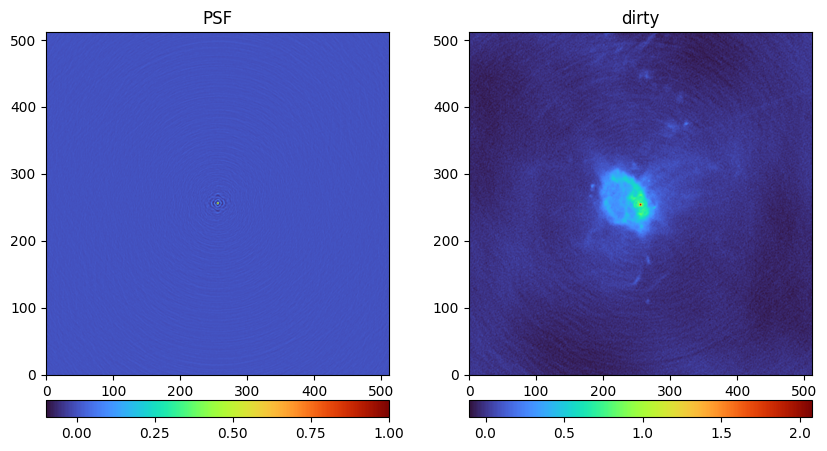

In [2]:
psf = util.fromfits("../data/SGRA_full_psf.fits")
dirty = util.fromfits("../data/SGRA_full_dirty.fits")
gt = util.fromfits("../data/SGRA_full_gt.fits")

util.plotNImages([psf, dirty], ["PSF", "dirty"], cmap=cmap)

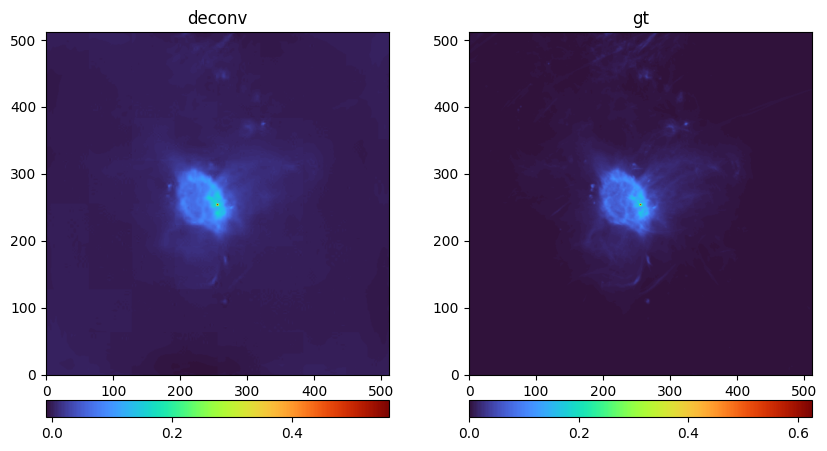

In [3]:
psf_fista = Filter2D(psf)

deconvolved = fista.fista(psf_fista, dirty, 0.002, wavelets, 100, linear_conv=True)
util.plotNImages([deconvolved, gt], ["deconv", "gt"], cmap=cmap)

## Multipartition test

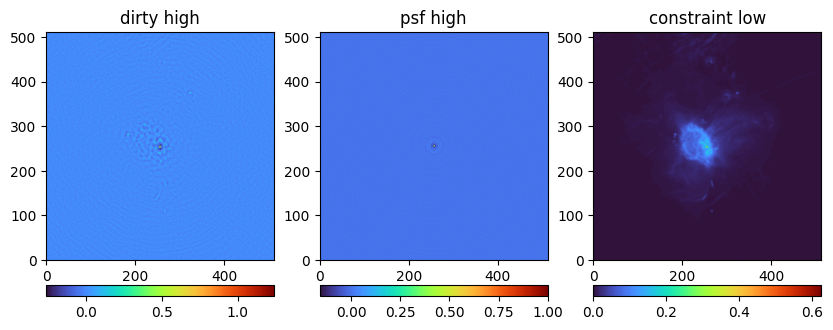

In [4]:
dataset = "SGRA"
dirty_high = util.fromfits("../data/SGRA_high34_dirty.fits")
psf_high = util.fromfits("../data/SGRA_high34_psf.fits")

util.plotNImages([dirty_high, psf_high, gt], ["dirty high", "psf high", "constraint low"], cmap=cmap)


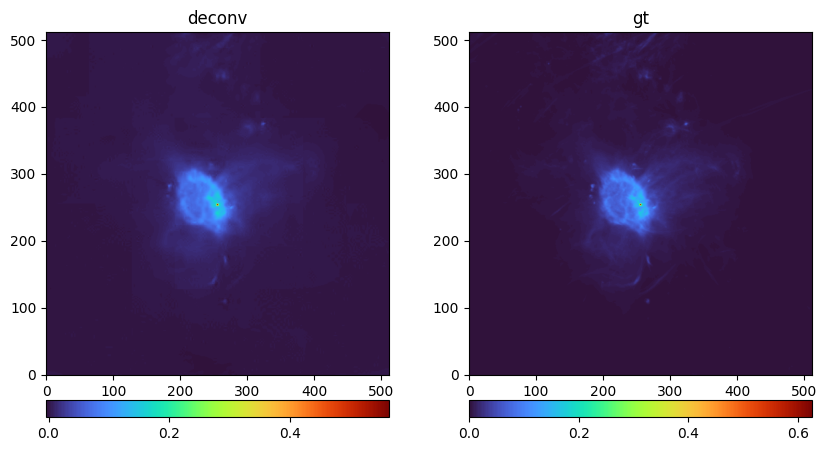

In [11]:
psf_fista_high = Filter2D(psf_high)
constraints = [gt, dirty_high]

sigma2s = []

for c in constraints:
    sigma2s.append(numpy.mean(helpers.compute_windowed_var(c, 5)))
    
frs, _, _ = filters.create_filters_mstep(psf_high.shape[0] // 2, [1], [35], sigma2s)
frns = [numpy.array(fr) for fr in frs]
fs2ds = [filters.freq1d_to_radial2d(f1d, psf_high.shape[0])[1] for f1d in frns]

filts = []
for f in fs2ds:
    filts.append(Filter2D(f))

deconvolved_mp = fista.fista(psf_fista_high, dirty_high, 0.002, wavelets, 100, partition=1,\
                          parallelize_wavelets=False, filters=filts, constraint_images=constraints, linear_conv=True)

util.plotNImages([deconvolved_mp, gt], ["deconv", "gt"], cmap=cmap)

## Speed comparison to Julia implementation

Precompiling DeconvMultiStep...
    812.4 ms  ✓ Reexport
    803.0 ms  ✓ DelimitedFiles
    801.8 ms  ✓ StaticArraysCore
    816.8 ms  ✓ IterTools
    797.4 ms  ✓ IUWT
    817.9 ms  ✓ Statistics
    798.9 ms  ✓ Compat
    815.2 ms  ✓ Requires
    882.2 ms  ✓ AbstractFFTs
    802.7 ms  ✓ ConstructionBase
    816.0 ms  ✓ OrderedCollections
    798.1 ms  ✓ DocStringExtensions
    801.6 ms  ✓ ProgressMeter
    800.2 ms  ✓ Preferences
    804.9 ms  ✓ IrrationalConstants
    267.4 ms  ✓ ConstructionBase → ConstructionBaseLinearAlgebraExt
    275.9 ms  ✓ Compat → CompatLinearAlgebraExt
    293.9 ms  ✓ PrecompileTools
    339.0 ms  ✓ JLLWrappers
    395.5 ms  ✓ LogExpFunctions
    568.8 ms  ✓ Statistics → SparseArraysExt
   1647.6 ms  ✓ MacroTools
    433.2 ms  ✓ FFTW_jll
    464.5 ms  ✓ oneTBB_jll
    501.8 ms  ✓ OpenSpecFun_jll
    863.2 ms  ✓ AbstractFFTs → AbstractFFTsTestExt
    855.1 ms  ✓ IntelOpenMP_jll
   1036.8 ms  ✓ RecipesBase
    762.7 ms  ✓ Setfield
    746.2 ms  ✓ MKL_jll
   167

locator: <matplotlib.ticker.AutoLocator object at 0x7b6734af0970>
locator: <matplotlib.ticker.AutoLocator object at 0x7b673427e890>


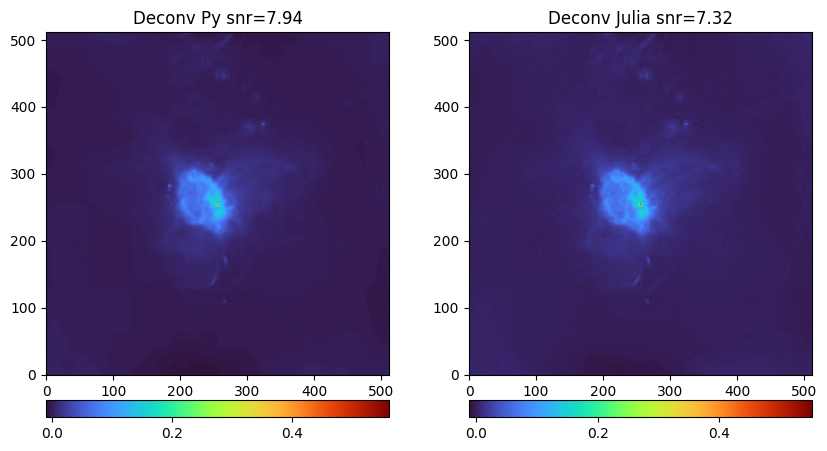

Time python: 14.548759460449219
Time julia: 76.76249623298645


In [15]:
start_py = time.time()
deconv_py = fista.fista(psf_fista, dirty, 0.002, wavelets, 100,parallelize_wavelets=False, linear_conv=True)
end_py=time.time()

psf_name = "tmp_psf.fits"
dirty_name = "tmp_dirty.fits"
out_name = "tmp_out.fits"

util.tofits(psf, psf_name)
util.tofits(dirty, dirty_name)

start_julia = time.time()
os.system("julia ../interleaved_parallelization_prototype/julia/make_fullres_mp.jl 0.002 " + psf_name + \
              " " + dirty_name + " 0 100 " + out_name)
end_julia = time.time()

deconv_julia = helpers.readFits(out_name)

snr_py = evaluation.compute_snr(gt, deconv_py)
snr_julia = evaluation.compute_snr(gt, deconv_julia)

util.plotNImages([deconv_py, deconv_julia], ["Deconv Py snr=" + "{:0.2f}".format(snr_py), "Deconv Julia snr=" + "{:0.2f}".format(snr_julia)], cmap=cmap)
print("Time python: " + str(end_py - start_py))
print("Time julia: " + str(end_julia - start_julia))

## Serial vs Parallel implementation

Times, serial-parallel: 9.933303833007812 : 32.52939772605896
locator: <matplotlib.ticker.AutoLocator object at 0x7b6735d83e20>
locator: <matplotlib.ticker.AutoLocator object at 0x7b67356bdd80>


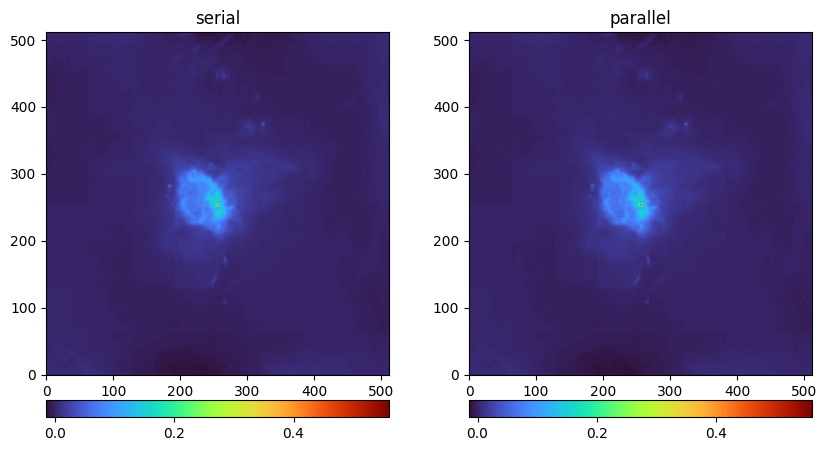

In [16]:
psf_fista = Filter2D(psf)

start_serial = time.time()
deconv_serial = fista.fista(psf_fista, dirty, 0.002, wavelets, 100,parallelize_wavelets=False)
end_serial=time.time()

start_parallel = time.time()
deconv_parallel = fista.fista(psf_fista, dirty, 0.002, wavelets, 100,parallelize_wavelets=True)
end_parallel=time.time()

print("Times, serial-parallel: " + str(end_serial-start_serial) + " : " + str(end_parallel-start_parallel))

util.plotNImages([deconv_serial, deconv_parallel], ["serial", "parallel"], cmap=cmap)